# DATA37000 - Midterm Project -- Qicheng Jin

## Project Incentives  
Nowadays scams are everywhere, some attackers use computer aided or AI generated fake voice to steal money or data. Besides that, some verifications might include using voiceprint, and without fake voice detection, we will abuse unauthorized accesses.   To address these problems, I decided to build a fake voice detection model. 


## Dataset Description  
I found a dataset in Kaggle called “The Fake-or-Real (FoR) Dataset (deepfake audio)” which fits my project goals. This dataset consists of more than 10,000 voice samples, each sample is a 2 second audio of speech. There are two labels or two classes, one is “real”, that means the speech is from human, and the other one is “fake”, that means the speech is artificially generated.

In [3]:
import pandas as pd
import os
import librosa
from tqdm import tqdm
import numpy as np

## Data Cleaning and Preprocessing

### 1. remove silent audios
I discovered that there are no silent audio, so no need to remove any audios so far

In [4]:
def total_silent(root_dir):
    file_paths = []
    labels = []
   #  mfcc_features = []

    sub_dir =os.path.join(root_dir, "real")
    for file in os.listdir(sub_dir):
        if file.endswith("wav"):
            file_paths.append(os.path.join(sub_dir, file))
            labels.append(1)  # 1 is for real voice, 0 is for fake voice
    sub_dir =os.path.join(root_dir, "fake")
    for file in os.listdir(sub_dir):
        if file.endswith("wav"):
            file_paths.append(os.path.join(sub_dir, file))
            labels.append(0)  # 1 is for real voice, 0 is for fake voice
    
        # mfcc_transform = torchaudio.transforms.MFCC(n_mfcc = n_mfcc)

    count = 0
    for file_path in tqdm(file_paths):
        y, sr = librosa.load(file_path)
        if y is None or len(y) == 0 or np.allclose(y, 0):
            count += 1
    return count


train_audio_count = total_silent("/Users/mac/Desktop/DATA37000-25AU/DATA370-midterm-project/data/raw/for-2sec/for-2seconds/training")
valid_audio_count = total_silent("/Users/mac/Desktop/DATA37000-25AU/DATA370-midterm-project/data/raw/for-2sec/for-2seconds/validation")
test_audio_count = total_silent("/Users/mac/Desktop/DATA37000-25AU/DATA370-midterm-project/data/raw/for-2sec/for-2seconds/testing")

print(f"there are total of {train_audio_count + valid_audio_count + test_audio_count} silent audios that need to be removed")


100%|██████████| 1088/1088 [00:01<00:00, 957.08it/s]

there are total of 0 silent audios that need to be removed


### 2. convert audio data to tabular form with 50 features 
To prepare the data into tabular form that can use for numerical analysis and machine learning algorithms, I used a feature extraction algorithm called MFCC. MFCC (Mel Frequency Cepstral Coefficients) is used to represent the short term power spectrum of a sound. This feature is widely used in audio and speech tasks as it captures characteristics of sound that human perceives.   
After the data processing, now I have the dataset prepared in tabular form:   
a 17870 * 52 table (50 MFCCs, 1 label, 1 filpath)  

(the feature extraction code implementation can be found in src/extract_feature.py)

In [6]:
df1 = pd.read_csv("/Users/mac/Desktop/DATA37000-25AU/DATA370-midterm-project/data/processed/train_features.csv")
df2 = pd.read_csv("/Users/mac/Desktop/DATA37000-25AU/DATA370-midterm-project/data/processed/val_features.csv")
df3 = pd.read_csv("/Users/mac/Desktop/DATA37000-25AU/DATA370-midterm-project/data/processed/test_features.csv")

df = pd.concat([df1, df2, df3])
print(df.shape)

(17870, 52)


## Exploratory Data Analysis

summary statistics for each MFCC feature

In [7]:
df.describe()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,mfcc_42,mfcc_43,mfcc_44,mfcc_45,mfcc_46,mfcc_47,mfcc_48,mfcc_49,mfcc_50,labels
count,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000,...,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000,17870.000000
mean,-229.182395,126.534384,-26.443994,44.927524,-17.743433,4.256712,-16.725834,-5.144449,-14.292185,-5.167326,...,0.860682,-0.556844,1.084792,-0.670612,1.143850,-0.375415,0.580759,0.363031,0.115251,0.500000
std,42.652421,26.161611,17.321539,18.146196,15.883998,17.561463,13.424685,12.041883,9.023195,7.067303,...,3.358527,3.085604,2.814101,3.049707,2.644111,2.834018,2.663453,2.823404,2.508522,0.500014
min,-503.617860,14.726707,-114.838320,-23.143679,-69.104100,-48.750860,-62.979073,-52.653880,-50.129410,-38.848488,...,-10.705741,-10.909400,-10.866168,-12.381920,-8.151957,-13.504985,-10.382147,-9.570374,-7.839318,0.000000
25%,-255.859332,109.195960,-36.560716,32.910194,-29.599772,-9.046285,-25.940466,-15.087801,-19.967878,-9.940807,...,-1.475672,-2.700977,-0.882078,-2.875594,-0.726188,-2.401941,-1.217819,-1.677310,-1.577188,0.000000
50%,-226.063365,125.889067,-25.566130,45.954718,-16.860660,5.671578,-16.709551,-4.379413,-14.303268,-5.001461,...,0.364957,-0.899426,0.763304,-0.926757,0.862549,-0.515908,0.362069,0.253686,-0.135199,0.500000
75%,-198.924545,144.273770,-15.722644,57.539904,-6.073112,17.904367,-7.998008,4.444562,-8.829849,-0.421329,...,2.765410,1.257526,2.689994,1.328817,2.663340,1.470788,2.153338,2.137647,1.523089,1.000000
max,-31.026243,220.989850,54.580482,116.172460,49.210550,59.130684,30.210896,34.762990,27.162127,20.787428,...,20.628798,16.785997,20.057116,17.065094,17.152262,14.623589,16.078850,16.338438,15.274864,1.000000


check if the dataset is balanced with two classes (real vs fake)  
(1 is for real, 0 is for fake)  

The bar plot shows that they are balanced very well

<Axes: xlabel='labels'>

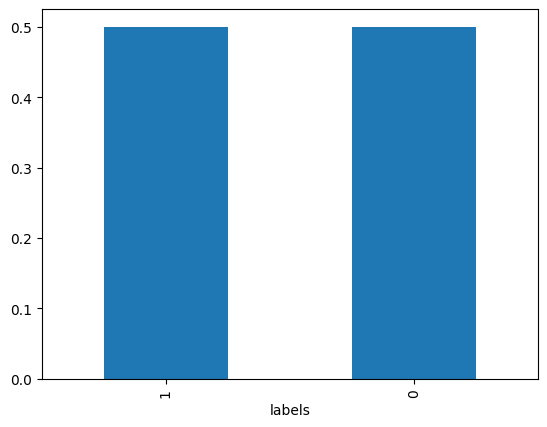

In [ ]:
df["labels"].value_counts(normalize=True).plot(kind="bar")


Based on the distribution of first 5 MFCC features, each 

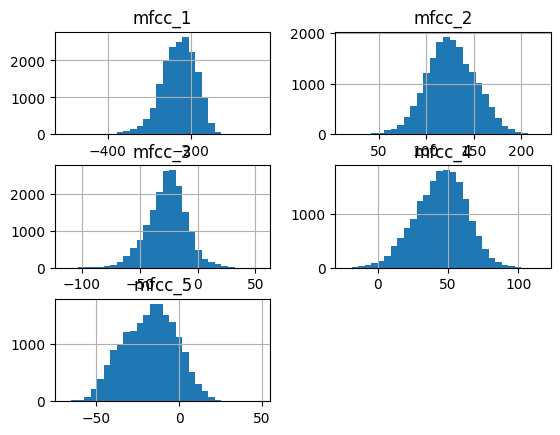

In [9]:
import matplotlib.pyplot as plt
df.iloc[:, :5].hist(bins=30)
plt.show()

Based on the plot, we can view correlations among all 50 MFCC features and we discovered that first few MFCC features are not highly correlated, and for higher coefficients (about mfcc_25 - mfcc_50), close MFCC features are highly correlated. But overall, only moderate correlations among all features, and it's a good thing to show diversity of information 

<Axes: >

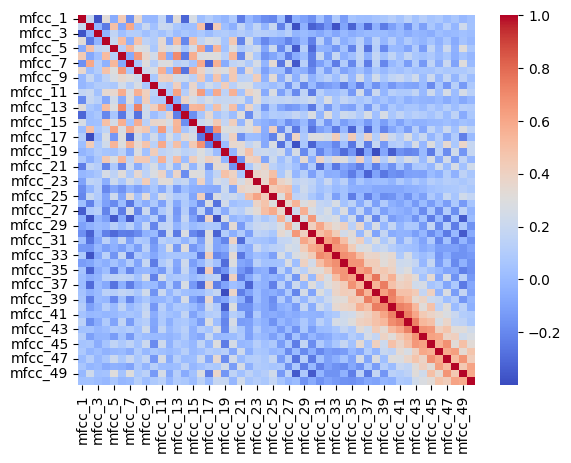

In [11]:
import seaborn as sns
corr = df.iloc[:, :-2].corr()
sns.heatmap(corr, cmap="coolwarm")


Based on these observations, MFCCS are pretty much normalized and not s0 correlated, so I don't need to do some data scaling after. 

## Machine Learning Models and Performance Comparison

I chose 4 models: logistic regression, decision tree, random forest, and KNN   
the model implementation can be found on src/model.py

## 1. visualization of test accuracy 

cl1: logistic regression, test_acc = 87%  

cl2: decision tree, test_acc = 93%  

cl3: random forest, test_acc = 99%  

cl4: KNN, test_acc = 96%


Based on the test accuracy, the random forest performs the best, achieving the highest accuracy. It's likely because it captures complex nonlinear relationships and is robust to overfitting since it's an ensumble model that basically consits of a bunch of decision trees.   

KNN also performs well, that shows local pattern recognition is working very well for the dataset.  

The decision tree has moderate performance and The logistic regression has the lowest accuracy. It suggests that the data-label relationship is not so linear. While logistic regression is the only linear model among all 4 models I chose, it struggles to fit the data.


(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

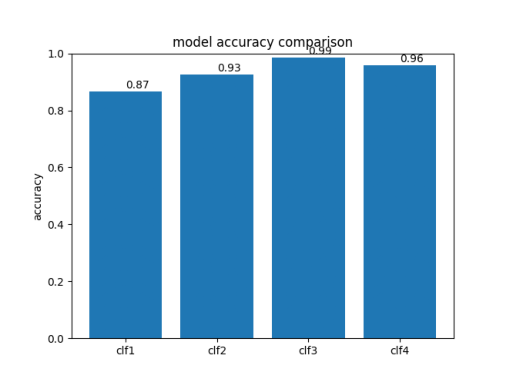

In [19]:
import matplotlib.image as mpimg
img = mpimg.imread("/Users/mac/Desktop/DATA37000-25AU/DATA370-midterm-project/media/accuracy_comp.png")
plt.imshow(img)
plt.axis("off")

## 2.visualization on model running time

cl1: logistic regression, run_time = 0.05   

cl2: decision tree, run_time = 1.00   

cl3: random forest, run_time = 6.74  

cl4: KNN, run_time = 0.16  


The random forest achieves the highest test accuracy, the trade off is that it runs the longest. This is expected, since it trains many trees and aggregates their results.  

The decision tree on the other hand runs faster since it trains a single tree. But it sacrifices the accuracy on test set, which means less robustness.  

KNN trains quickly as well, since we only store the positions of each training point, so not so much training happened. However, the real computational costs happen in prediction stage, since this is a large dataset, and we are going to find neighbors of the prediction target.

The Logistic regression trains the fastest, as its linear optimization process, however it sacrifices non-linearality, so runs fast but fits bad.

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

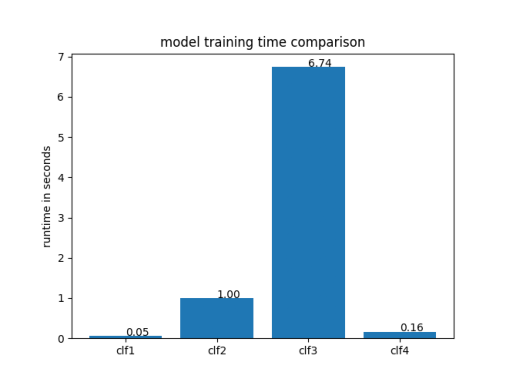

In [21]:
img = mpimg.imread("/Users/mac/Desktop/DATA37000-25AU/DATA370-midterm-project/media/runtime_comp.png")
plt.imshow(img)
plt.axis("off")

Overall, I will pick random forest as my model: It performs the best, the run time is reasonable. Here is the classification report of random forest:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1413
           1       0.98      0.99      0.99      1413

    accuracy                           0.99      2826
    macro avg      0.99      0.99      0.99      2826
    weighted avg   0.99      0.99      0.99      2826




In [28]:
report = pd.read_table("/Users/mac/Desktop/DATA37000-25AU/DATA370-midterm-project/media/random_forest_report.txt")
print(report)

             precision    recall  f1-score   support
0             0       0.99      0.98      0.99   ...
1             1       0.98      0.99      0.99   ...
2      accuracy                           0.99   ...
3     macro avg       0.99      0.99      0.99   ...
4  weighted avg       0.99      0.99      0.99   ...


## Discussion
Right now, I successfully build a model that can tell apart real and fake voice recordings that has great applications in autheticity verification processes and fraud prevention. That also shows that traditional machine learning models can achieve strong performance with good features even without deep learning.   

Among the models I evaluated, random forest achieved the highest performace. KNN and decision trees strike a balance between training time and accuracy. Logistic regression trained the fastest but struggled to capture the nonlinear nature of MFCC features. This also highlight trade-off between model complexity, training cost and prediction. 

In a real-world deployment, for e,g, in the backend development, we can record every 2 sec audio segment in real time, and go through the same feature extraction pipeline for prediction.   

There are limitations too: with the evolution of AI, future synthetic audios may be more resemble to human and be much harder to detect. In the future, we might need to constantly retrain and update the model with new data or adopt some deep learning models. 


## References

Abdeldayem, M. (2023). *The Fake-or-Real (FoR) Dataset* [Dataset]. York University, Toronto, Canada.  
Licensed under GNU Lesser General Public License 3.0.  
Retrieved from [https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset](https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset)
